In [1]:
import torch

In [2]:
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(torch.cuda.get_device_properties(i).name)
else:
    print('GPU not available!')

AMD Radeon RX 7800 XT
AMD Radeon Graphics


In [10]:
import json

with open('../data/saved_rivens/syam.json') as file:
    data = json.load(file)
    
print(data['orders'][0])

{'type': 'sell', 'user': {'status': 'offline'}, 'item': {'re_rolls': 33, 'type': 'riven', 'mod_rank': 8, 'polarity': 'vazarin', 'mastery_level': 12, 'weapon_url_name': 'syam', 'name': 'acri-critaum', 'attributes': [{'value': 15.9, 'positive': True, 'url_name': 'channeling_damage'}, {'value': 68.6, 'positive': True, 'url_name': 'critical_damage'}, {'value': 133.2, 'positive': True, 'url_name': 'critical_chance'}, {'value': -68.8, 'positive': False, 'url_name': 'puncture_damage'}]}, 'platinum': 888888}


In [16]:
orders = data['orders']
attributes_list = [order['item']['attributes'] for order in orders]
flatten_attributes = [attribute for attribute_list in attributes_list for attribute in attribute_list]
attribute_names = {attribute['url_name'] for attribute in flatten_attributes}

other_item_attributes = {'re_rolls', 'mod_rank'}

print(attribute_names)
print(other_item_attributes)

x_attributes = attribute_names.copy()
x_attributes.update(other_item_attributes)
print(x_attributes)

{'finisher_damage', 'status_chance', 'critical_damage', 'chance_to_gain_extra_combo_count', 'heat_damage', 'channeling_damage', 'range', 'critical_chance_on_slide_attack', 'status_duration', 'channeling_efficiency', 'cold_damage', 'base_damage_/_melee_damage', 'damage_vs_grineer', 'toxin_damage', 'combo_duration', 'damage_vs_infested', 'damage_vs_corpus', 'fire_rate_/_attack_speed', 'electric_damage', 'slash_damage', 'chance_to_gain_combo_count', 'puncture_damage', 'critical_chance'}
{'re_rolls', 'mod_rank'}
{'damage_vs_infested', 'finisher_damage', 'status_chance', 'damage_vs_corpus', 'critical_damage', 'fire_rate_/_attack_speed', 'electric_damage', 'chance_to_gain_extra_combo_count', 'heat_damage', 'channeling_damage', 'range', 'slash_damage', 'critical_chance_on_slide_attack', 'chance_to_gain_combo_count', 'mod_rank', 'status_duration', 'channeling_efficiency', 'cold_damage', 'base_damage_/_melee_damage', 're_rolls', 'puncture_damage', 'toxin_damage', 'damage_vs_grineer', 'critical_

In [55]:
def parse_order(order):
    item = order['item']
    item_attributes = {attribute['url_name']: attribute['value'] for attribute in item['attributes']}

    price = order['platinum']
    attribute_values = {}
    for attribute_name in attribute_names:
        attribute_values[attribute_name] = item_attributes.get(attribute_name) or 0

    for attribute_name in other_item_attributes:
        attribute_values[attribute_name] = item.get(attribute_name) or 0
    
    return attribute_values, price

In [56]:
parse_order(orders[0])

({'finisher_damage': 0,
  'status_chance': 0,
  'critical_damage': 68.6,
  'chance_to_gain_extra_combo_count': 0,
  'heat_damage': 0,
  'channeling_damage': 15.9,
  'range': 0,
  'critical_chance_on_slide_attack': 0,
  'status_duration': 0,
  'channeling_efficiency': 0,
  'cold_damage': 0,
  'base_damage_/_melee_damage': 0,
  'damage_vs_grineer': 0,
  'toxin_damage': 0,
  'combo_duration': 0,
  'damage_vs_infested': 0,
  'damage_vs_corpus': 0,
  'fire_rate_/_attack_speed': 0,
  'electric_damage': 0,
  'slash_damage': 0,
  'chance_to_gain_combo_count': 0,
  'puncture_damage': -68.8,
  'critical_chance': 133.2,
  're_rolls': 33,
  'mod_rank': 8},
 888888)

In [57]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [58]:
X = [list(parse_order(order)[0].values()) for order in orders]
y = [parse_order(order)[1] for order in orders]

print(X)
print(y)

print(f'[Sanity Check] Number of plat prices matches number of rivens: {len(X) == len(y)}')

[[0, 0, 68.6, 0, 0, 15.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -68.8, 133.2, 33, 8], [0, 0, 0, 0, 0, 0, 0, -8.0, 0, 0, 0, 12.5, 0, 0, 0, 0, 0, 0, 7.6, 0, 0, 0, 14.3, 17, 0], [0, 0, 63.1, 0, 0, 0, 0, 0, 0, 0, 0, 112.6, 0, 0, 0, 0, 0, 0, 0, 0, 0, -61.0, 122.3, 54, 8], [0, 0, 62.2, 0, 0, 0, 0, 0, 0, -38.3, 0, 115.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 133.3, 116, 8], [0, 0, 61.2, 0, 0, 0, 0, 0, 0, 0, 0, 104.4, 0, 0, 0, 0, 0, 0, 0, -60.9, 0, 0, 121.1, 17, 8], [0, 0, 69.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -72.2, 0, 86.5, 133.4, 10, 8], [0, 0, 66.3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.33, 0, 0, 0, 0, 0, 0, -64.3, 0, 0, 115.3, 17, 8], [-62.8, 0, 64.8, 0, 0, 17.6, 0, 0, 0, 0, 0, 123.3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 199, 8], [0, 0, 65.9, 0, 0, 0, 0, 0, 0, 0, 0, 123.6, 0, 0, 0, 0, 0, 0, 0, -68.5, 0, 0, 119.7, 25, 8], [0, 0, 66.8, 0, 0, 0, -1.0, 0, 0, 0, 0, 113.3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 115.5, 19, 8], [-69.6, 0, 57.1, 0, 0, 0, 1.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 38.1, 0, 0, 0, 

from torch.utils.data import Dataset


class RivenDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [588]:
from torch import nn

number_of_attributes = len(x_attributes)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.hidden_layer1 = nn.Linear(number_of_attributes, 32)
        self.hidden_layer2 = nn.Linear(32, 16)
        self.hidden_layer3 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = torch.relu(self.hidden_layer3(x))
        x = self.output(x)
        return x.squeeze(-1)

In [589]:
import random

def split_data(x, y, ratio=0.5, seed=2):
    assert len(x) == len(y)
    split_index = int(len(x) * ratio)

    x_shuffle = x.copy()
    random.Random(seed).shuffle(x_shuffle)

    y_shuffle = y.copy()
    random.Random(seed).shuffle(y_shuffle)

    return x_shuffle[:split_index], x_shuffle[split_index:], y_shuffle[:split_index], y_shuffle[split_index:]

In [597]:
from torch.utils.data import DataLoader, random_split, TensorDataset

X_train, X_test, y_train, y_test = split_data(X, y, 0.5)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# dataset = TensorDataset(X_tensor, y_tensor)
#
# training_data, test_data = random_split(dataset, [0.8, 0.2])
#
# train_dataloader = DataLoader(training_data, shuffle=True)
# test_dataloader = DataLoader(test_data, shuffle=True)

In [620]:
from torch import optim

model = NeuralNetwork().to(device)
print(model)

loss_function = nn.MSELoss(reduction='none').to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

NeuralNetwork(
  (hidden_layer1): Linear(in_features=25, out_features=32, bias=True)
  (hidden_layer2): Linear(in_features=32, out_features=16, bias=True)
  (hidden_layer3): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
)


In [621]:
num_epochs = 500
epoch = 0

loss_values = []

for epoch in range(num_epochs):
    model.train()
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.mean().backward()
    optimizer.step()

    train_loss = loss.mean().item()
    loss_values.append(train_loss)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        loss = loss_function(y_pred, y_test_tensor)
        test_loss = loss.mean().item()

    print(f'[Epoch {epoch}] Train MSE: {train_loss:.4f} Test MSE: {test_loss:.4f}')


[Epoch 0] Train MSE: 2112118.2500 Test MSE: 3423741184.0000
[Epoch 1] Train MSE: 2111918.0000 Test MSE: 3423740416.0000
[Epoch 2] Train MSE: 2111710.7500 Test MSE: 3423739136.0000
[Epoch 3] Train MSE: 2111498.2500 Test MSE: 3423738112.0000
[Epoch 4] Train MSE: 2111282.0000 Test MSE: 3423736576.0000
[Epoch 5] Train MSE: 2111068.5000 Test MSE: 3423735040.0000
[Epoch 6] Train MSE: 2110849.7500 Test MSE: 3423733248.0000
[Epoch 7] Train MSE: 2110624.2500 Test MSE: 3423730944.0000
[Epoch 8] Train MSE: 2110386.5000 Test MSE: 3423729664.0000
[Epoch 9] Train MSE: 2110133.2500 Test MSE: 3423728640.0000
[Epoch 10] Train MSE: 2109858.5000 Test MSE: 3423726592.0000
[Epoch 11] Train MSE: 2109565.2500 Test MSE: 3423724032.0000
[Epoch 12] Train MSE: 2109240.0000 Test MSE: 3423721472.0000
[Epoch 13] Train MSE: 2108880.5000 Test MSE: 3423718400.0000
[Epoch 14] Train MSE: 2108486.7500 Test MSE: 3423715840.0000
[Epoch 15] Train MSE: 2108045.2500 Test MSE: 3423712512.0000
[Epoch 16] Train MSE: 2107567.2500

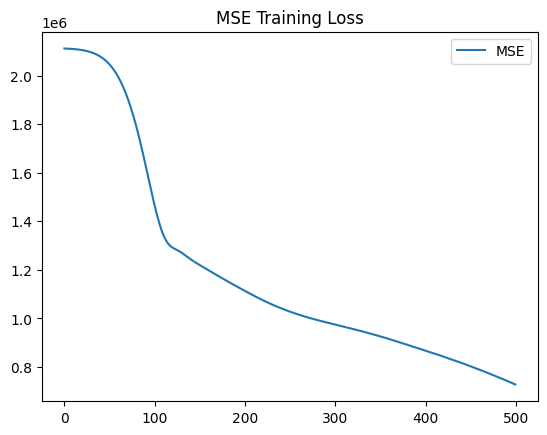

In [622]:
import matplotlib.pyplot as plt

plt.plot(loss_values, label='MSE')
plt.legend()
plt.title('MSE Training Loss')
plt.show()

In [623]:
y_train = []
y_train_pred = []

model.eval()
with torch.no_grad():
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)

    y_train.extend([y.item() for y in y_train_tensor])
    y_train_pred.extend([y.item() for y in y_pred])

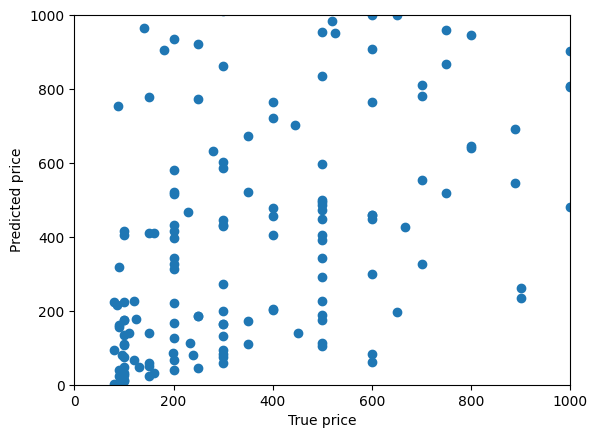

In [624]:
lim = [0, 1e3]

plt.scatter(y_train, y_train_pred)
plt.xlabel('True price')
plt.ylabel('Predicted price')
plt.xlim(lim)
plt.ylim(lim)
plt.show()

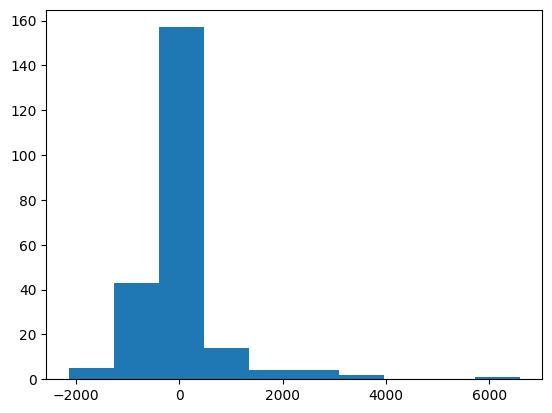

In [625]:
residuals = [y_true - y_pred for y_true, y_pred in zip(y_train, y_train_pred)]

plt.hist(residuals)
plt.show()

In [626]:
y_test = []
y_test_pred = []

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    loss = loss_function(y_pred, y_test_tensor)

    y_test.extend([y.item() for y in y_test_tensor])
    y_test_pred.extend([y.item() for y in y_pred])

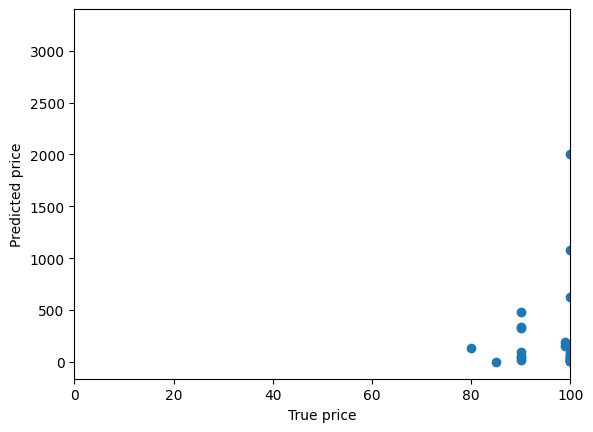

In [631]:
lim = [0, 1e3]

plt.scatter(y_test, y_test_pred)
plt.xlabel('True price')
plt.ylabel('Predicted price')
plt.xlim(lim)
plt.ylim(lim)
plt.show()

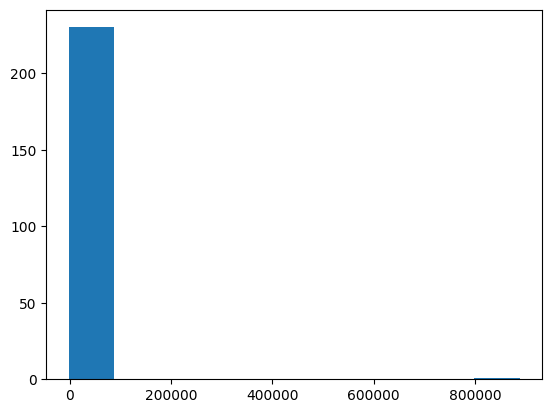

In [611]:
residuals = [y_true - y_pred for y_true, y_pred in zip(y_test, y_test_pred)]

plt.hist(residuals)
plt.show()

In [551]:
import pathlib

model_save_path = pathlib.Path('../data/model.dat')
torch.save(model, model_save_path)

model = NeuralNetwork()
model.load_state_dict(model_save_path)

TypeError: Expected state_dict to be dict-like, got <class 'pathlib._local.PosixPath'>.